# Statistical Analysis — UCI Bank Marketing Dataset

**Author:** Naunihal Sidhu  
**Project:** Udacity — Project 2: Data and Statistical Reasoning

This notebook performs a complete statistical analysis: data ingestion, descriptive statistics, visualizations, and one hypothesis test.

## Contents
1. Environment Validation
2. Load Dataset
3. Descriptive Statistics
4. Visualizations
5. Hypothesis Test
6. Summary

## 1. Environment Validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print('numpy', np.__version__)
print('pandas', pd.__version__)
print('scipy', stats.__name__, '/ scipy module loaded')
sns.set_theme(style='whitegrid')

numpy 2.4.4
pandas 3.0.2
scipy scipy.stats / scipy module loaded


## 2. Load Dataset

**Dataset:** UCI Bank Marketing — `bank-additional-full.csv`  
**Source:** [UCI Machine Learning Repository, ID 222](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
**Reference:** Moro, S., Cortez, P., & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing.* Decision Support Systems, 62, 22–31.

The data records direct-marketing phone campaigns by a Portuguese banking institution. Each row is one client contact; the binary target `y` records whether the client subscribed to a term deposit.

The CSV uses `;` as the field delimiter and encodes unknown categorical values as the literal string `"unknown"`.

In [2]:
import io
import os
import urllib.request
import zipfile

DATA_DIR = 'data'
DATA_PATH = os.path.join(DATA_DIR, 'bank-additional-full.csv')
SOURCE_URL = 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip'


def ensure_dataset(path: str = DATA_PATH, url: str = SOURCE_URL) -> str:
    """Download the UCI Bank Marketing CSV from `url` if `path` is missing."""
    if os.path.exists(path):
        print(f'Using cached dataset: {path}')
        return path

    print(f'Dataset not found at {path}. Downloading from {url} ...')
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with urllib.request.urlopen(url) as resp:
        outer = zipfile.ZipFile(io.BytesIO(resp.read()))
    with outer.open('bank-additional.zip') as inner_fp:
        inner = zipfile.ZipFile(io.BytesIO(inner_fp.read()))
    target = next(n for n in inner.namelist() if n.endswith('bank-additional-full.csv'))
    with inner.open(target) as src, open(path, 'wb') as dst:
        dst.write(src.read())
    print(f'Saved dataset to {path}')
    return path


ensure_dataset()
df = pd.read_csv(DATA_PATH, sep=';')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Using cached dataset: data\bank-additional-full.csv
Shape: 41,188 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print('Column dtypes:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isna().sum())
print('\n"unknown" counts in string columns:')
print((df.select_dtypes(include='str') == 'unknown').sum().loc[lambda s: s > 0])

Column dtypes:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed      

## 3. Descriptive Statistics

I look at three things: numeric summaries (`df.describe`), categorical frequencies, and the shape of a few key numeric distributions. The aim is to understand the data before any test, and to flag values that may need care later (e.g. heavy skew, sentinel codes).

In [4]:
df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


**Notes on numeric summaries:**
- `age` ranges from 17 to 98 with mean ~40 — plausible adult-customer range.
- `duration` (last contact length, seconds) is highly right-skewed: mean ~258s but max 4918s. The dataset documentation warns this variable is only known *after* the call ends, so it leaks the outcome and is unsuitable as a predictor; I keep it for descriptive context only.
- `pdays` has a sentinel value `999` meaning "client was not previously contacted". The mean (~962) is therefore not a real average of days — it reflects that most clients are first-time contacts.
- `campaign` and `previous` are right-skewed counts.
- The macro-economic columns (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) vary little within the file because the data spans a single economic period.

In [5]:
cat_cols = df.select_dtypes(include='str').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}\n')
for col in cat_cols:
    counts = df[col].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(2)
    print(f'--- {col} ({df[col].nunique()} unique) ---')
    print(pd.DataFrame({'count': counts, 'pct': pct}).head(12))
    print()

Categorical columns (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

--- job (12 unique) ---
               count    pct
job                        
admin.         10422  25.30
blue-collar     9254  22.47
technician      6743  16.37
services        3969   9.64
management      2924   7.10
retired         1720   4.18
entrepreneur    1456   3.54
self-employed   1421   3.45
housemaid       1060   2.57
unemployed      1014   2.46
student          875   2.12
unknown          330   0.80

--- marital (4 unique) ---
          count    pct
marital               
married   24928  60.52
single    11568  28.09
divorced   4612  11.20
unknown      80   0.19

--- education (8 unique) ---
                     count    pct
education                        
university.degree    12168  29.54
high.school           9515  23.10
basic.9y              6045  14.68
professional.course   5243  12.73
basic.4y              4176  10.14
basic.6y 

**Notes on categorical frequencies:**
- Target `y` is highly imbalanced: about **88.7% "no"** vs **11.3% "yes"**. Any test or model has to account for this.
- `job` is dominated by *admin.*, *blue-collar*, and *technician*.
- `education` includes *unknown* (~4.2%); `default` is almost entirely *no* with a large *unknown* slice and only 3 *yes* rows — effectively a near-constant column.
- `month` is uneven: *may* alone is ~33% of contacts, with *dec*/*mar*/*sep*/*oct* very small. This means month-based comparisons must be read carefully.
- `poutcome` is *nonexistent* for ~86% of rows (no prior campaign).

In [6]:
print('Target balance:')
print((df['y'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

print('\nSubscription rate by job:')
print((df.groupby('job')['y'].apply(lambda s: (s == 'yes').mean()) * 100)
      .round(2).sort_values(ascending=False).astype(str) + ' %')

key_numeric = ['age', 'duration', 'campaign', 'euribor3m']
print('\nSkewness of key numeric variables:')
print(df[key_numeric].skew().round(2))

Target balance:
y
no     88.73 %
yes    11.27 %
Name: proportion, dtype: str

Subscription rate by job:
job
student          31.43 %
retired          25.23 %
unemployed        14.2 %
admin.           12.97 %
management       11.22 %
unknown          11.21 %
technician       10.83 %
self-employed    10.49 %
housemaid         10.0 %
entrepreneur      8.52 %
services          8.14 %
blue-collar       6.89 %
Name: y, dtype: str

Skewness of key numeric variables:
age          0.78
duration     3.26
campaign     4.76
euribor3m   -0.71
dtype: float64


**Notes on group differences and shape:**
- The overall subscription rate is ~11%; by `job` it ranges from below 7% (*blue-collar*, *services*) to above 25% (*student*, *retired*) — a substantial spread that motivates the hypothesis test in Section 5.
- `duration` and `campaign` are strongly right-skewed (skew >> 1), so any inference on them should prefer non-parametric or robust methods, or work on a transformed scale.
- `age` is mildly right-skewed; `euribor3m` is approximately bimodal because it tracks the policy-rate regime over the campaign period.

## 4. Visualizations

Four figures, each chosen to expose a property of the data that matters for the hypothesis test in Section 5:

1. **Age distribution** — checks shape and outliers of the main numeric variable.
2. **Subscription rate by job** — shows the group-level signal that motivates the test.
3. **Age by subscription outcome** — visual comparison of the two outcome groups.
4. **Correlation heatmap of numeric variables** — flags collinearity in the macro-economic block.

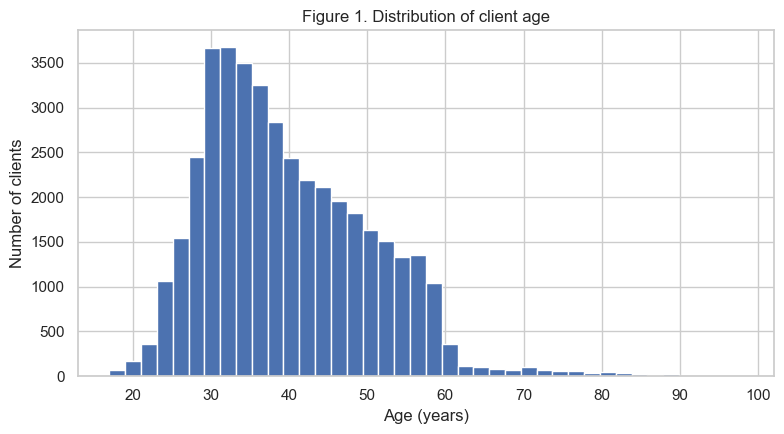

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df['age'], bins=40, color='#4C72B0', edgecolor='white')
ax.set_title('Figure 1. Distribution of client age')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of clients')
plt.tight_layout()
plt.show()

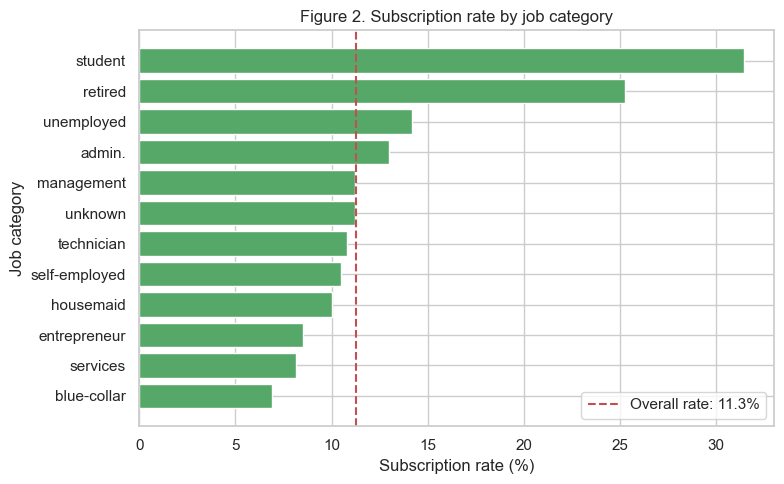

In [8]:
rates = (df.groupby('job')['y'].apply(lambda s: (s == 'yes').mean()) * 100
        ).sort_values()
overall = (df['y'] == 'yes').mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rates.index, rates.values, color='#55A868')
ax.axvline(overall, color='#C44E52', linestyle='--',
           label=f'Overall rate: {overall:.1f}%')
ax.set_title('Figure 2. Subscription rate by job category')
ax.set_xlabel('Subscription rate (%)')
ax.set_ylabel('Job category')
ax.legend()
plt.tight_layout()
plt.show()

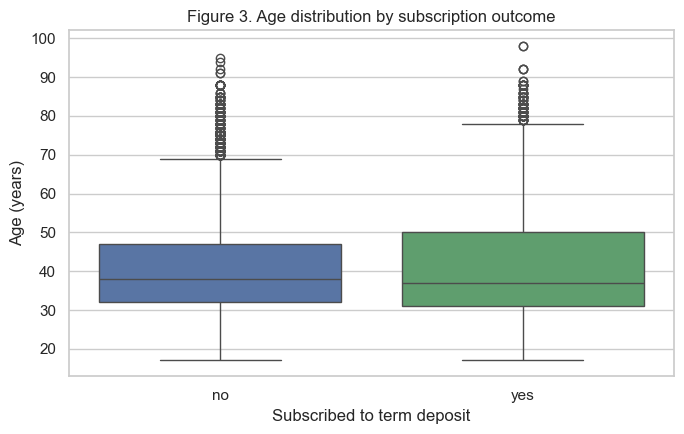

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x='y', y='age', order=['no', 'yes'],
            hue='y', hue_order=['no', 'yes'], legend=False,
            palette=['#4C72B0', '#55A868'], ax=ax)
ax.set_title('Figure 3. Age distribution by subscription outcome')
ax.set_xlabel('Subscribed to term deposit')
ax.set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

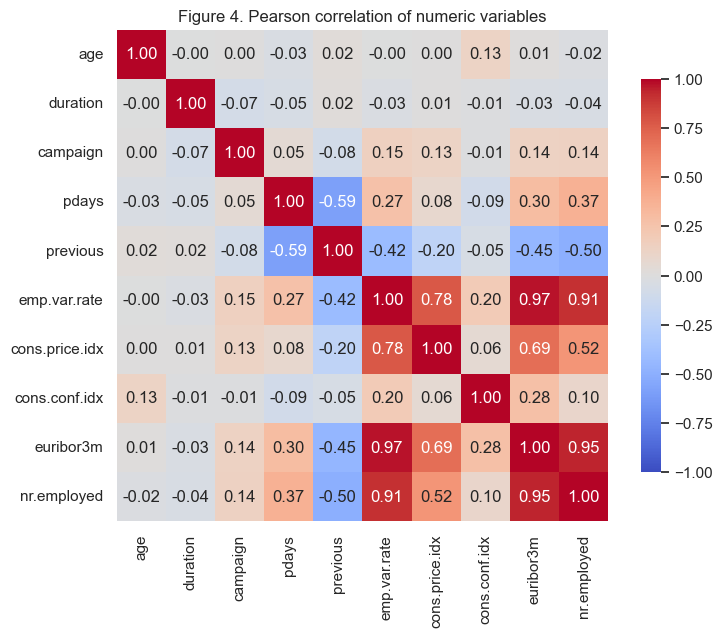

In [10]:
num_df = df.select_dtypes(include=['int64', 'float64'])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Figure 4. Pearson correlation of numeric variables')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Reading the figures:**
- **Figure 1.** Age is right-skewed with a long upper tail; most clients are 30–50.
- **Figure 2.** *Students* and *retired* clients subscribe at 25–31%, well above the 11.3% overall rate; *blue-collar* and *services* sit below 9%. The spread across job categories is the pattern formally tested in Section 5.
- **Figure 3.** Median age is similar across outcomes, but subscribers ("yes") show a wider spread, with more older clients — consistent with the high "retired" rate in Figure 2.
- **Figure 4.** The macro-economic block (`emp.var.rate`, `euribor3m`, `nr.employed`, `cons.price.idx`) is highly intercorrelated (|r| > 0.75). For modeling later, only one of these should be kept; for the present hypothesis test it is not an issue.

## 5. Hypothesis Test

**Question.** Is the rate at which clients subscribe to a term deposit independent of their job category, or does subscription depend on job?

**Test.** Pearson chi-square test of independence on the contingency table of `job` (12 categories) × `y` (yes / no). The chi-square test is appropriate because both variables are categorical, observations are independent (one row per client contact), and — as we will verify — every expected cell count is ≥ 5, so the asymptotic chi-square approximation is valid.

**Hypotheses.**
- $H_0$: subscription outcome is independent of job category (no association).
- $H_1$: subscription outcome is associated with job category.

Significance level: $\alpha = 0.05$.

In [11]:
contingency = pd.crosstab(df['job'], df['y'])
print('Observed counts:')
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
min_expected = expected.min()
n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f'\nChi-square statistic: {chi2:.4f}')
print(f'Degrees of freedom : {dof}')
print(f'p-value            : {p_value:.4e}')
print(f'Min expected count : {min_expected:.2f}  (assumption: >= 5)')
print(f"Cramer's V (effect size): {cramers_v:.4f}")

Observed counts:
y                no   yes
job                      
admin.         9070  1352
blue-collar    8616   638
entrepreneur   1332   124
housemaid       954   106
management     2596   328
retired        1286   434
self-employed  1272   149
services       3646   323
student         600   275
technician     6013   730
unemployed      870   144
unknown         293    37

Chi-square statistic: 961.2424
Degrees of freedom : 11
p-value            : 4.1898e-199
Min expected count : 37.18  (assumption: >= 5)
Cramer's V (effect size): 0.1528


**Result.** $\chi^2 = 961.24$ on $dof = 11$, $p \approx 4.2 \times 10^{-199}$. We reject $H_0$ at $\alpha = 0.05$ — subscription outcome is **not** independent of job category.

The minimum expected cell count is 37.2 (well above 5), so the chi-square approximation is appropriate. Cramer's V $= 0.153$ indicates a small-to-moderate association: the effect is real and statistically clear, but job alone explains only a modest portion of the variation in outcome — consistent with Figure 2, where most jobs cluster near the overall 11.3% rate while *student* and *retired* stand out.

Full interpretation, including practical meaning and limitations, is in `Statistical_Analysis_Report.pdf`.

## 6. Summary

I explored the UCI Bank Marketing dataset (41,188 contacts, 21 columns) to understand which client characteristics relate to subscribing to a term deposit. Descriptive statistics revealed a strongly imbalanced target (≈11.3% subscribe), heavy right-skew in `duration` and `campaign`, and several categorical columns containing the sentinel value `unknown`. The most interesting finding was the wide spread in subscription rates across job categories — *students* (31%) and *retired* clients (25%) subscribe at more than double the overall rate, while *blue-collar* (7%) and *services* (8%) sit well below it. A chi-square test of independence between `job` and `y` confirmed this association is statistically significant ($\chi^2 = 961.24$, $dof = 11$, $p \approx 4.2 \times 10^{-199}$), with a small-to-moderate effect size (Cramer's V = 0.15). The main challenges were the sentinel encodings (`999` for `pdays`, `unknown` in categorical columns) and the strong collinearity in the macro-economic block, both of which would need explicit handling before any modeling step. A small reproducibility note: I used a download-with-cache helper for the dataset so the notebook runs from a clean clone without manual file placement.